In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

In [28]:

base = 'D:/SEMESTER 6/magang things/DATA/'

BG     = 'white'
CARD   = '#F5F5F5'
TEXT   = '#1A1A1A'
MUTED  = '#666666'
LSTM_C = 'indigo'
GRU_C  = 'crimson'

sensors = {
    'Indoor ESP'   : 'inesp',
    'Indoor Raspi' : 'inpi3',
    'Outdoor ESP'  : 'outesp',
    'Outdoor Raspi': 'outpi3',
}
horizons = [10, 30, 60]

# ── Baca semua file performa 
performa = {}
for sensor, folder in sensors.items():
    performa[sensor] = {}
    for h in horizons:
        lstm = pd.read_excel(f'{base}{folder}/LSTM/Performa_LSTM_THI_{h}.xlsx')
        gru  = pd.read_excel(f'{base}{folder}/GRU/Performa_GRU_THI_{h}.xlsx')
        performa[sensor][h] = {
            'R_LSTM'   : lstm['R'].values[0],
            'RMSE_LSTM': lstm['RMSE'].values[0],
            'MAPE_LSTM': lstm['MAPE'].values[0],
            'R_GRU'    : gru['R'].values[0],
            'RMSE_GRU' : gru['RMSE'].values[0],
            'MAPE_GRU' : gru['MAPE'].values[0]
        }

# ── Baca semua file hasil prediksi 
hasil = {}
for sensor, folder in sensors.items():
    hasil[sensor] = {}
    for h in horizons:
        lstm = pd.read_excel(f'{base}{folder}/LSTM/LSTM_THI_{h}.xlsx')
        gru  = pd.read_excel(f'{base}{folder}/GRU/GRU_THI_{h}.xlsx')
        hasil[sensor][h] = {'lstm': lstm, 'gru': gru}

# ── Baca semua file loss 
loss = {}
for sensor, folder in sensors.items():
    loss[sensor] = {}
    for h in horizons:
        lstm = pd.read_excel(f'{base}{folder}/LSTM/LSTM_Loss_{h}.xlsx')
        gru  = pd.read_excel(f'{base}{folder}/GRU/GRU_Loss_{h}.xlsx')
        loss[sensor][h] = {'lstm': lstm, 'gru': gru}

print('Semua file berhasil dibaca!')

Semua file berhasil dibaca!


### **tabel performa seluruh model**

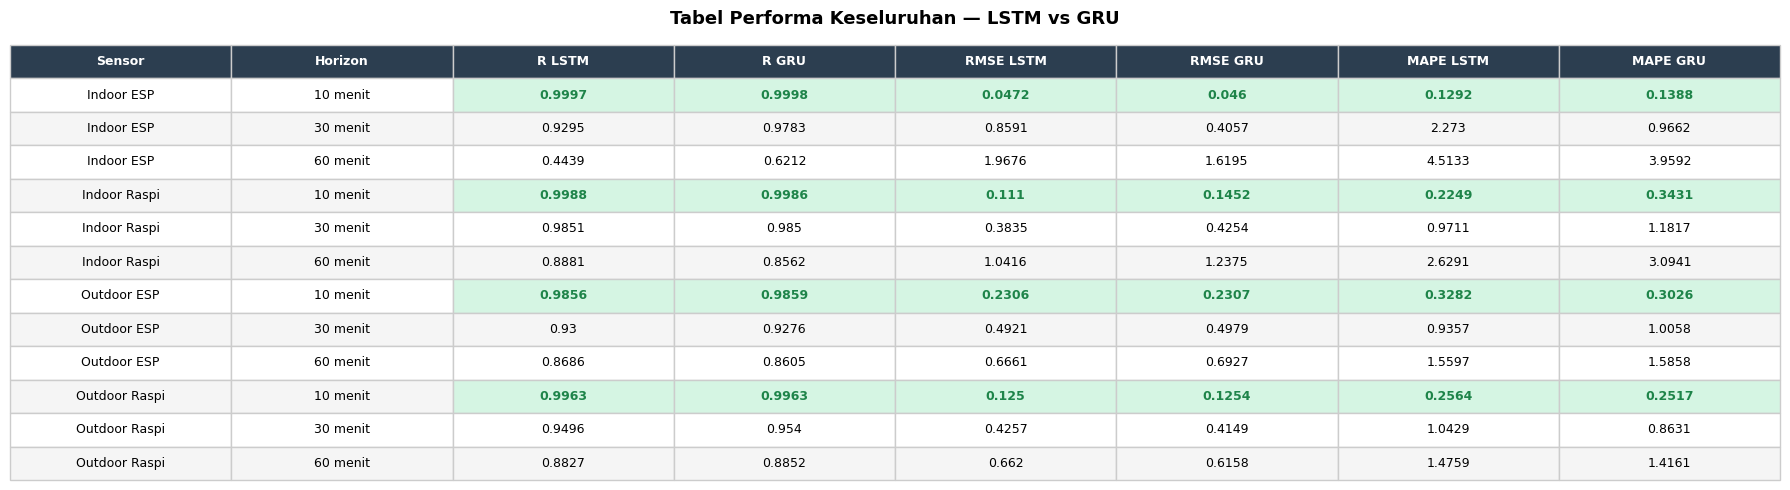

✅ Tabel tersimpan!


In [21]:
# Tabel performa dengan highlight terbaik per sensor per kolom metrik
rows = []
for sensor in sensors:
    for h in horizons:
        p = performa[sensor][h]
        rows.append({
            'Sensor'   : sensor,
            'Horizon'  : f'{h} menit',
            'R LSTM'   : round(p['R_LSTM'],    4),
            'R GRU'    : round(p['R_GRU'],     4),
            'RMSE LSTM': round(p['RMSE_LSTM'], 4),
            'RMSE GRU' : round(p['RMSE_GRU'],  4),
            'MAPE LSTM': round(p['MAPE_LSTM'], 4),
            'MAPE GRU' : round(p['MAPE_GRU'],  4),
        })

df_all = pd.DataFrame(rows)

# Tentukan mana yang terbaik per sensor per kolom metrik
# R → lebih tinggi lebih baik
# RMSE, MAPE → lebih rendah lebih baik
higher_better = ['R LSTM', 'R GRU']
lower_better  = ['RMSE LSTM', 'RMSE GRU', 'MAPE LSTM', 'MAPE GRU']

# Buat set index yang perlu di-hijau
highlight = set()
for sensor in sensors:
    idx = df_all[df_all['Sensor'] == sensor].index
    for col in higher_better:
        best_idx = df_all.loc[idx, col].idxmax()
        highlight.add((best_idx, col))
    for col in lower_better:
        best_idx = df_all.loc[idx, col].idxmin()
        highlight.add((best_idx, col))

# Plot tabel
fig, ax = plt.subplots(figsize=(18, 5), facecolor='white')
ax.axis('off')
ax.set_title('Tabel Performa Keseluruhan — LSTM vs GRU',
             fontsize=13, fontweight='bold', pad=15)

table = ax.table(
    cellText=df_all.values,
    colLabels=df_all.columns.tolist(),
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(9)

col_list = df_all.columns.tolist()

for (r, c), cell in table.get_celld().items():
    cell.set_edgecolor('#CCCCCC')
    if r == 0:
        cell.set_facecolor('#2C3E50')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#F5F5F5')
    else:
        cell.set_facecolor('white')

    # Highlight terbaik per sensor per kolom
    if r > 0:
        row_idx = r - 1
        col_name = col_list[c]
        if (row_idx, col_name) in highlight:
            cell.set_facecolor('#D5F5E3')
            cell.set_text_props(color='#1E8449', fontweight='bold')

plt.tight_layout()
plt.savefig('D:/SEMESTER 6/magang things/DATA/Tabel_Performa_Highlight.pdf',
            bbox_inches='tight')
plt.show()
df_all.to_excel('D:/SEMESTER 6/magang things/DATA/Tabel_Performa_Highlight.xlsx', index=False)
print('✅ Tabel tersimpan!')

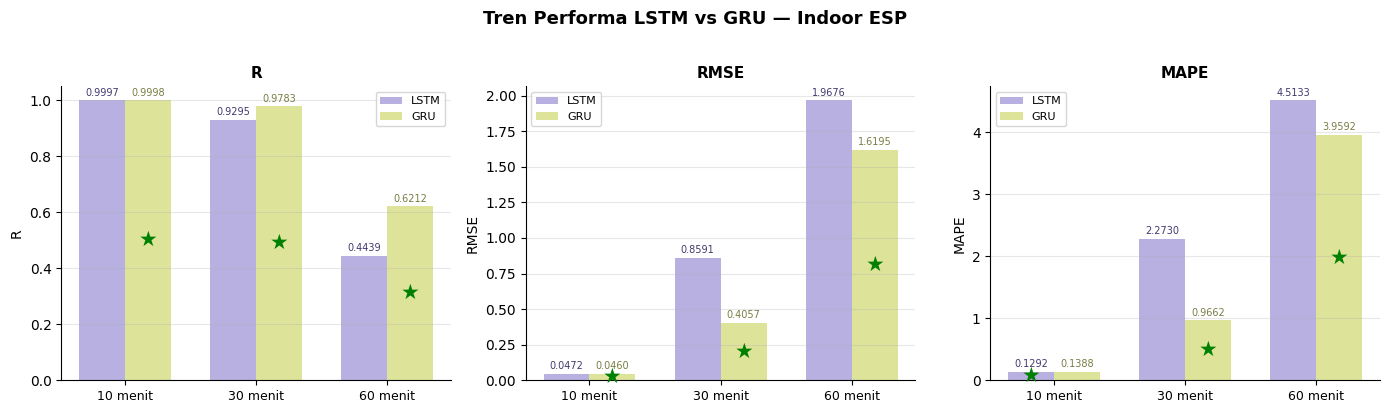

 Indoor ESP tersimpan!


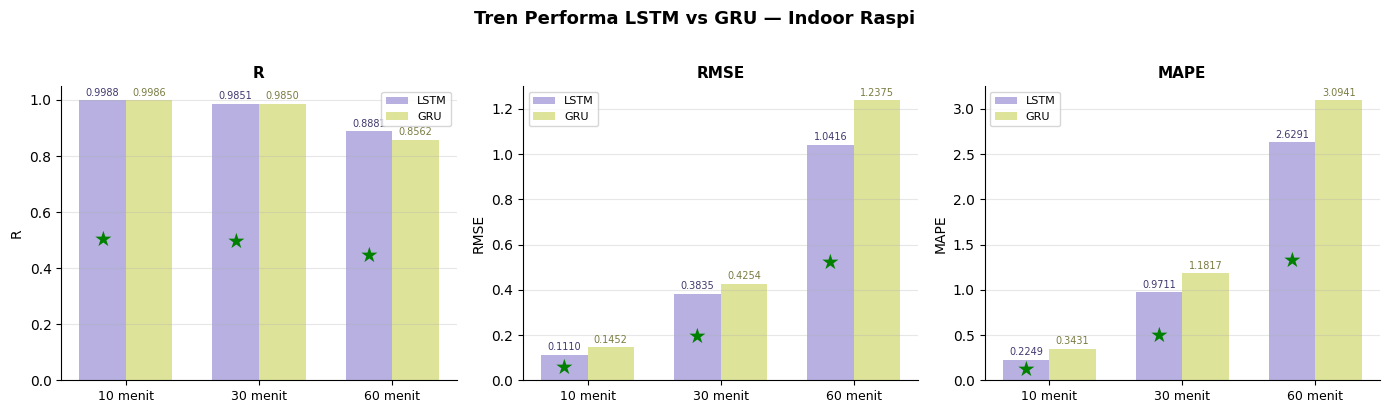

 Indoor Raspi tersimpan!


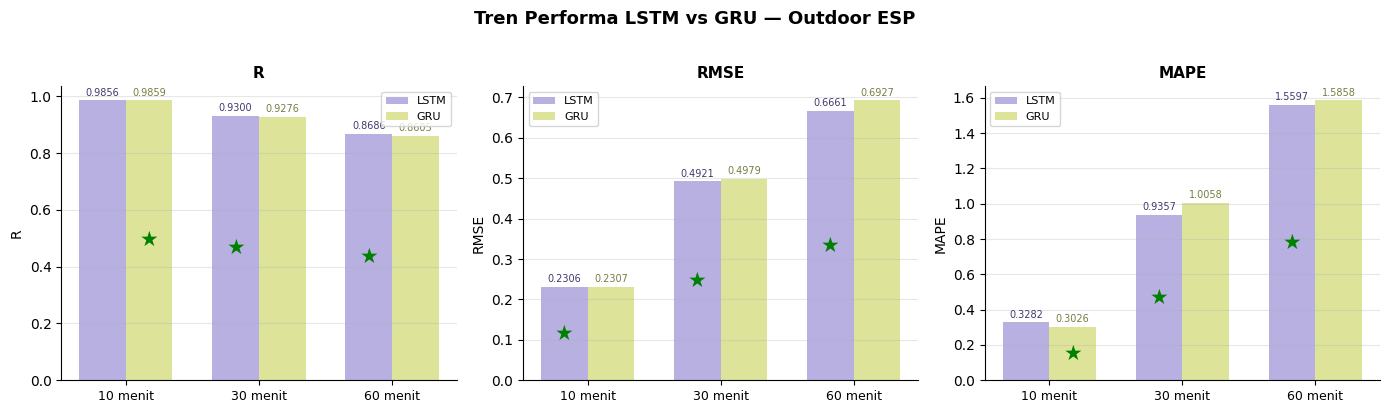

 Outdoor ESP tersimpan!


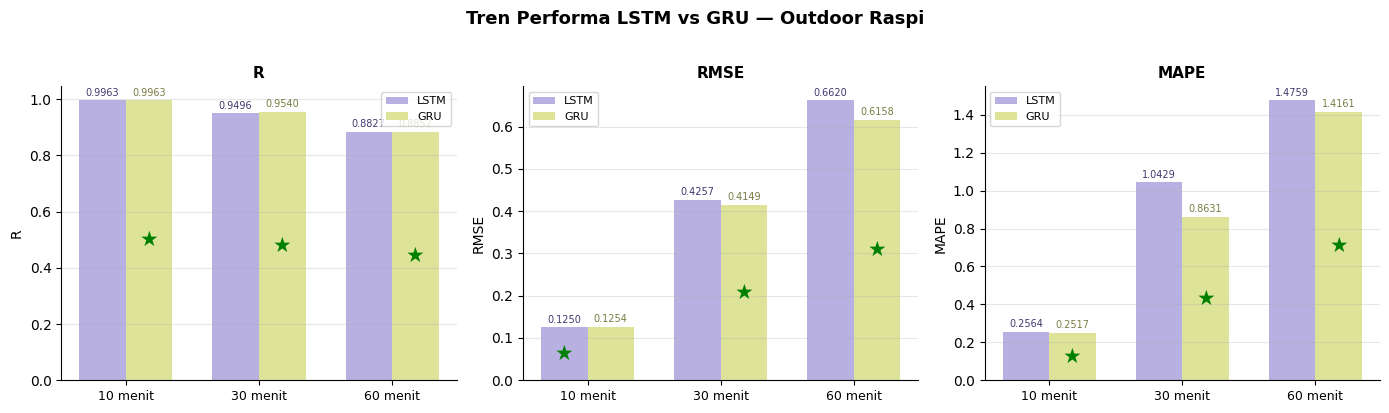

 Outdoor Raspi tersimpan!


In [22]:
import numpy as np

metrics = {
    'R'   : ('R_LSTM',    'R_GRU',    True),   # higher better
    'RMSE': ('RMSE_LSTM', 'RMSE_GRU', False),  # lower better
    'MAPE': ('MAPE_LSTM', 'MAPE_GRU', False),  # lower better
}

horizons_label = ['10 menit', '30 menit', '60 menit']
x = np.arange(len(horizons_label))
width = 0.35

for sensor in sensors:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4), facecolor='white')
    fig.suptitle(f'Tren Performa LSTM vs GRU — {sensor}',
                 fontsize=13, fontweight='bold', y=1.02)

    for ax, (metric, (col_lstm, col_gru, higher_better)) in zip(axes, metrics.items()):
        
        lstm_vals = [performa[sensor][h][col_lstm] for h in horizons]
        gru_vals  = [performa[sensor][h][col_gru]  for h in horizons]

        bars1 = ax.bar(x - width/2, lstm_vals, width,
                       color="#ABA3DC", alpha=0.85, label='LSTM')
        bars2 = ax.bar(x + width/2, gru_vals,  width,
                       color="#D9DE88", alpha=0.85, label='GRU')

        # Highlight terbaik per horizon
        for i, (lv, gv) in enumerate(zip(lstm_vals, gru_vals)):
            if higher_better:
                best_bar  = bars1[i] if lv > gv else bars2[i]
                best_val  = lv if lv > gv else gv
                best_name = 'LSTM' if lv > gv else 'GRU'
            else:
                best_bar  = bars1[i] if lv < gv else bars2[i]
                best_val  = lv if lv < gv else gv
                best_name = 'LSTM' if lv < gv else 'GRU'


            # Tambah tanda ★ dan label "Best" di atas bar terbaik
            ax.text(
                best_bar.get_x() + best_bar.get_width()/2,
                best_val / 2,  
                '★',
                ha='center', va='center',
                fontsize=15, color='green', fontweight='bold'
            )

        # Angka di atas bar
        for bar in bars1:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + max(lstm_vals + gru_vals)*0.01,
                    f'{bar.get_height():.4f}',
                    ha='center', va='bottom', fontsize=7, color="#40396E")
        for bar in bars2:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + max(lstm_vals + gru_vals)*0.01,
                    f'{bar.get_height():.4f}',
                    ha='center', va='bottom', fontsize=7, color="#797C42")

        ax.set_title(metric, fontsize=11, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(horizons_label, fontsize=9)
        ax.set_ylabel(metric)
        ax.legend(fontsize=8)
        ax.grid(axis='y', alpha=0.3)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.tight_layout()
    fname = f'D:/SEMESTER 6/magang things/DATA/Barchart_{sensor.replace(" ", "_")}.pdf'
    plt.savefig(fname, bbox_inches='tight')
    plt.show()
    print(f' {sensor} tersimpan!')

### **perbandingan**

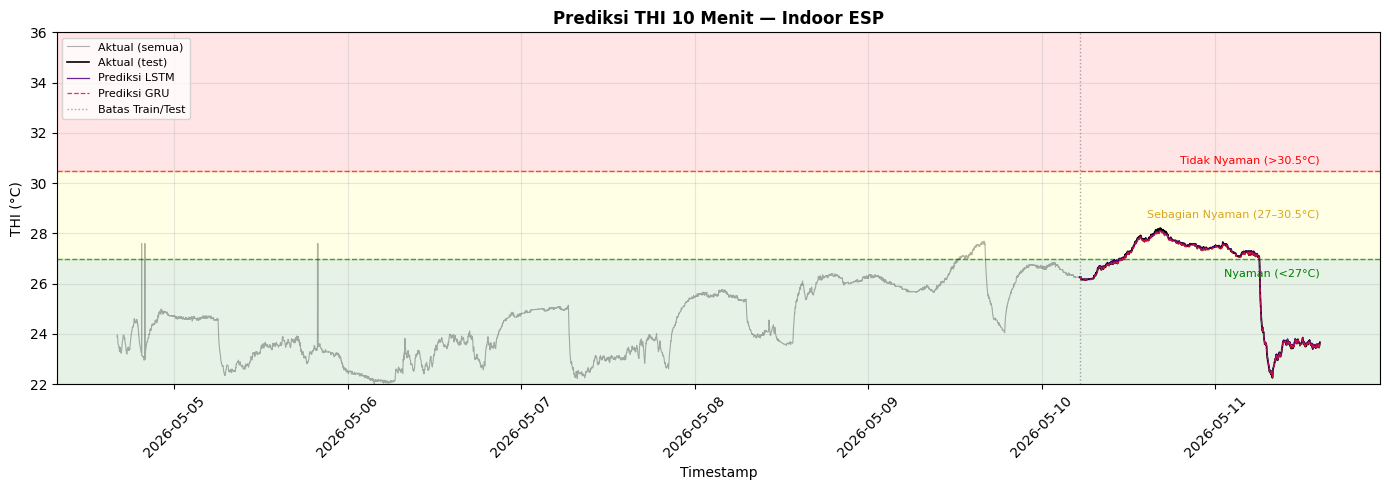

✅ Indoor ESP — 10 menit tersimpan!


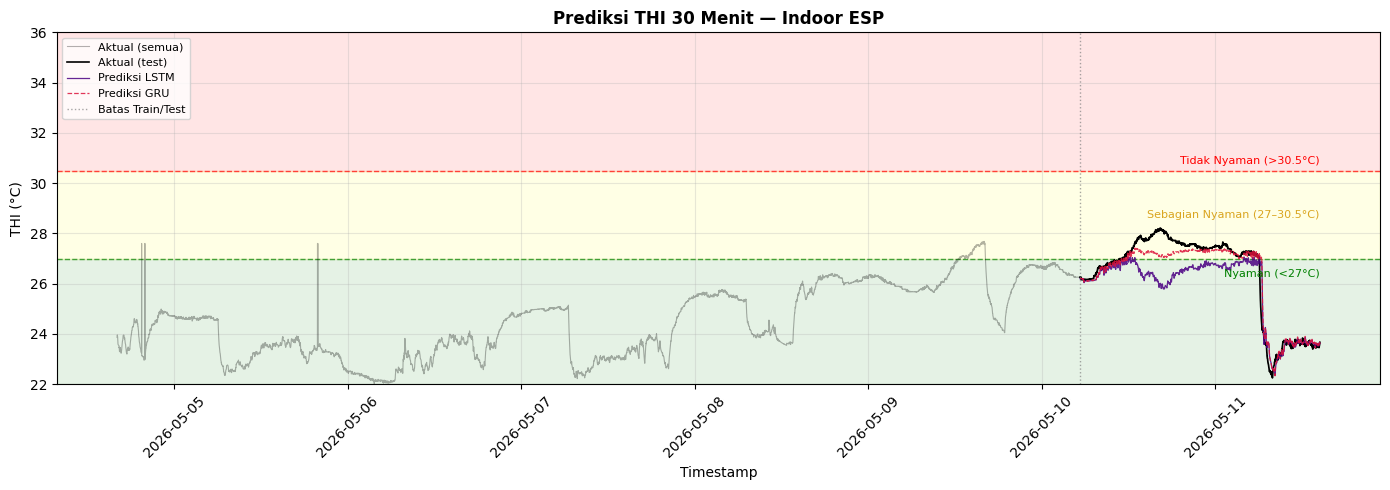

✅ Indoor ESP — 30 menit tersimpan!


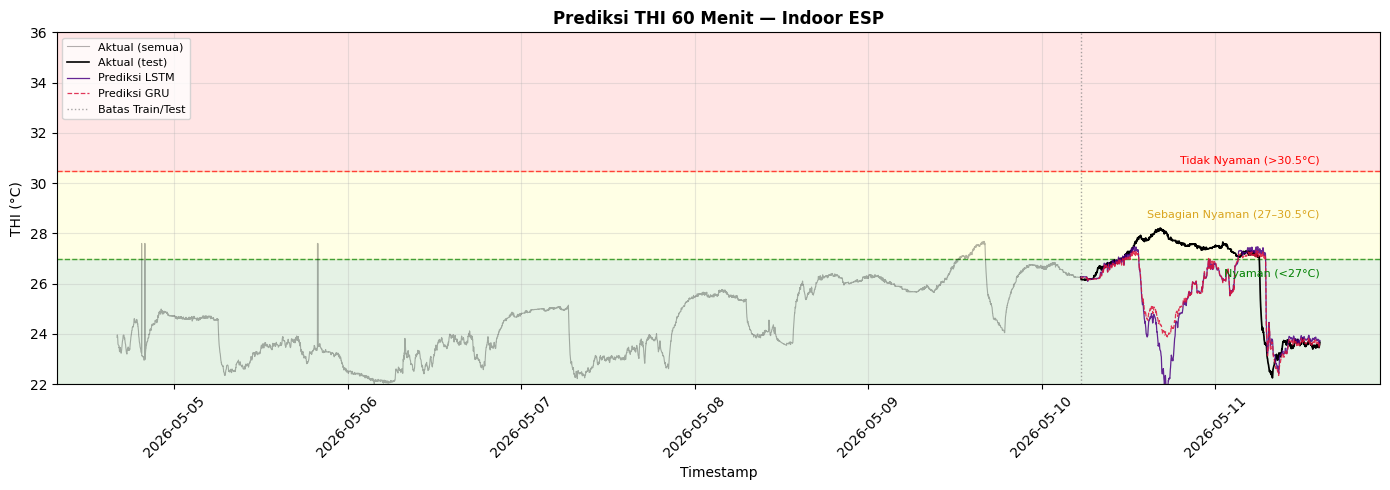

✅ Indoor ESP — 60 menit tersimpan!


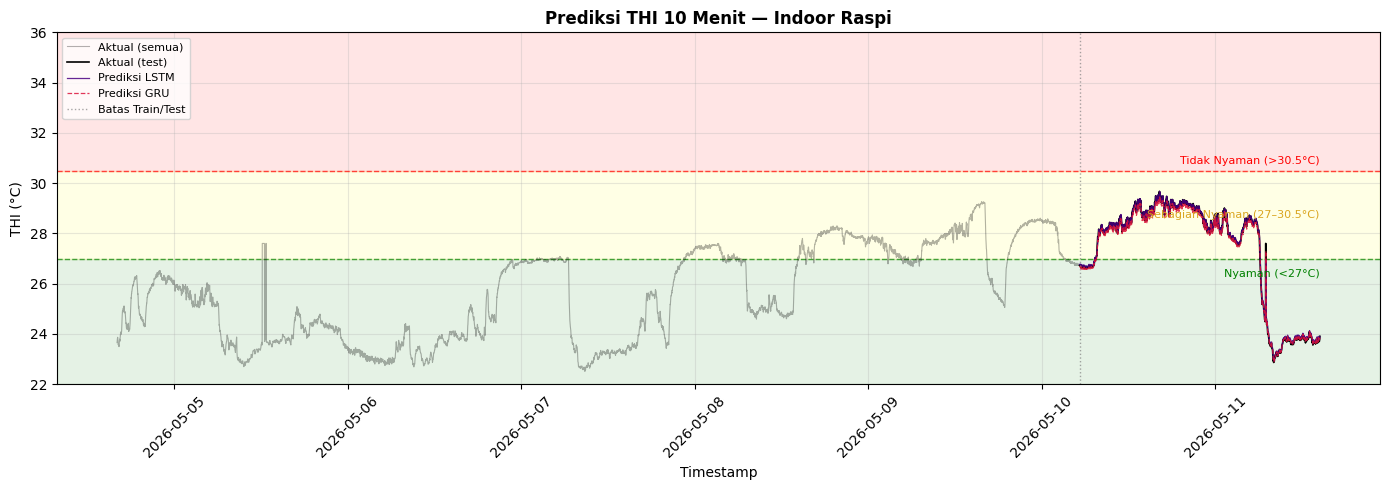

✅ Indoor Raspi — 10 menit tersimpan!


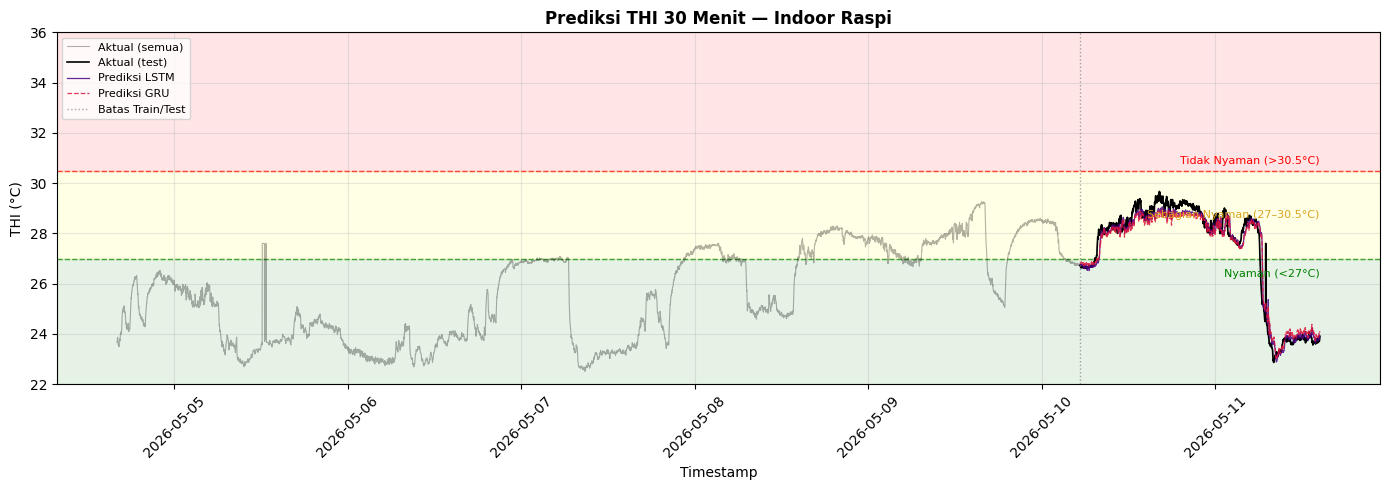

✅ Indoor Raspi — 30 menit tersimpan!


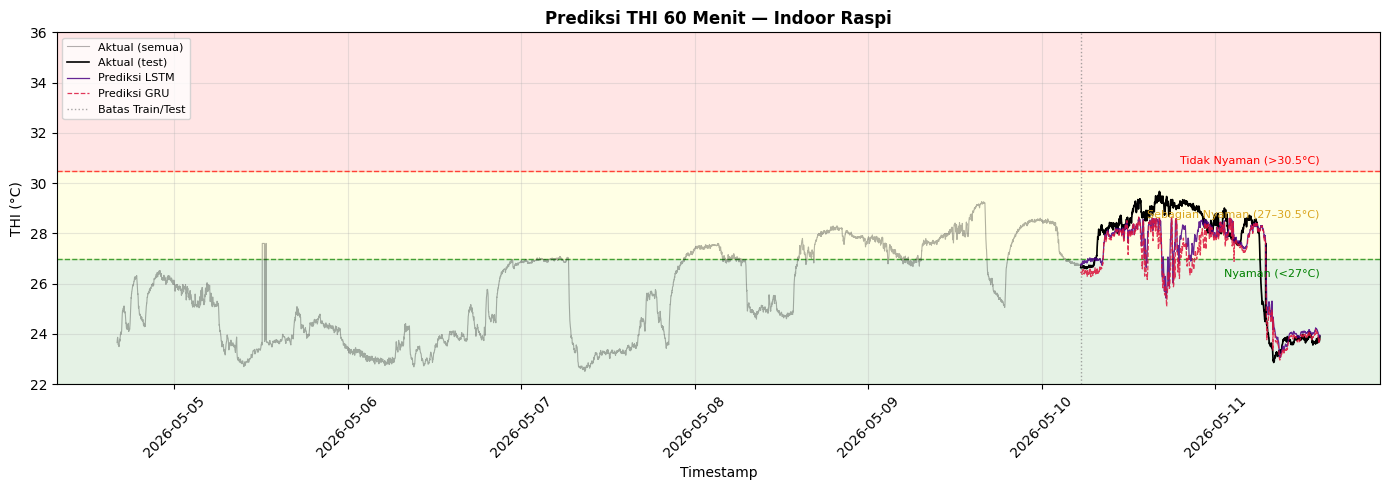

✅ Indoor Raspi — 60 menit tersimpan!


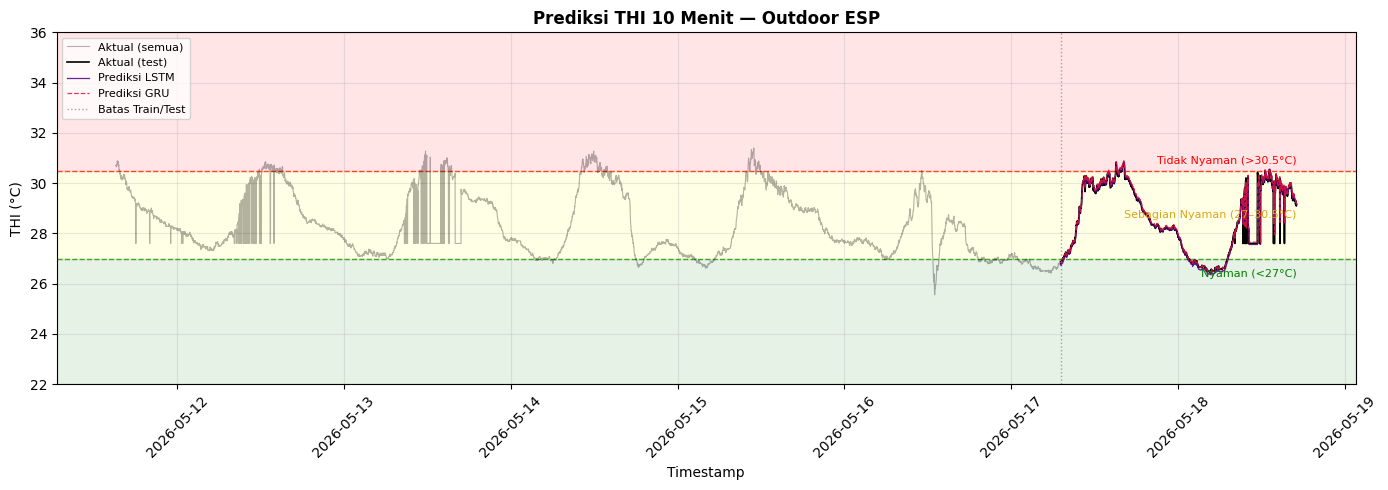

✅ Outdoor ESP — 10 menit tersimpan!


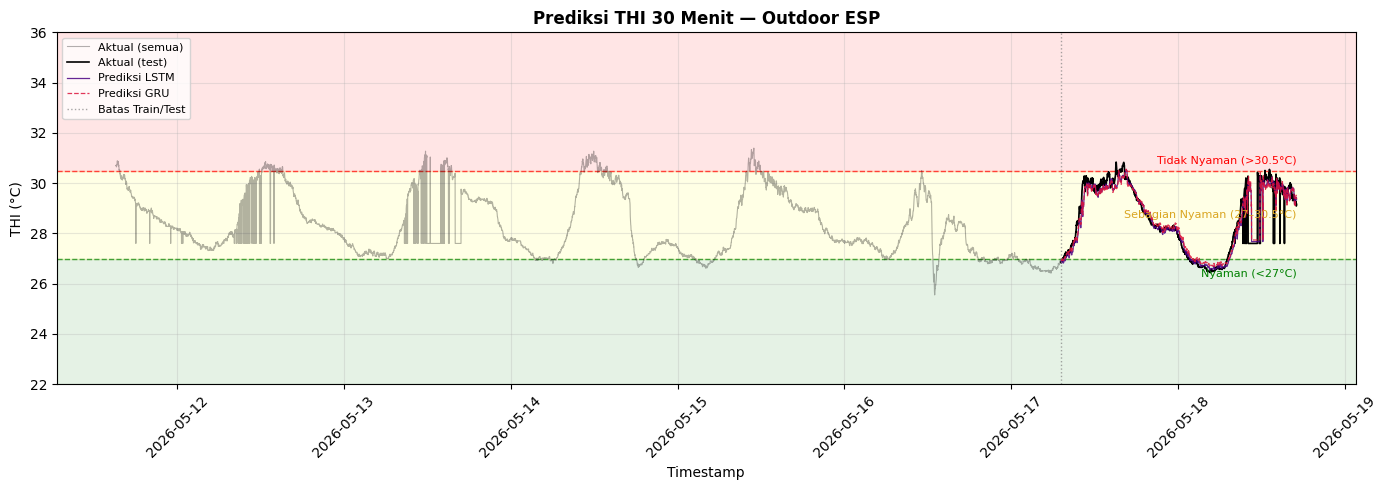

✅ Outdoor ESP — 30 menit tersimpan!


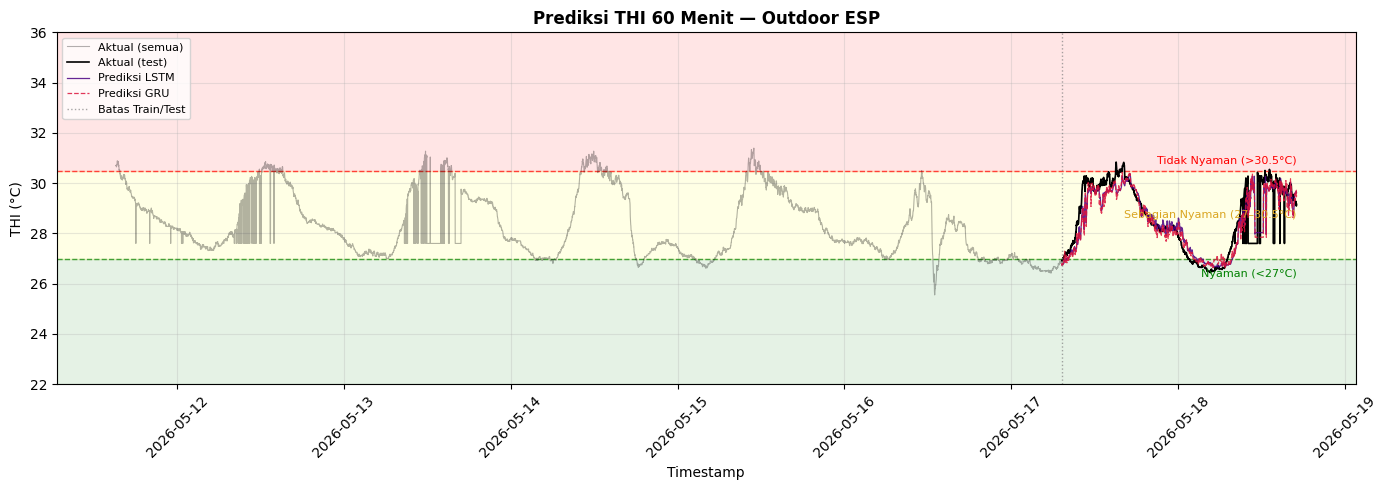

✅ Outdoor ESP — 60 menit tersimpan!


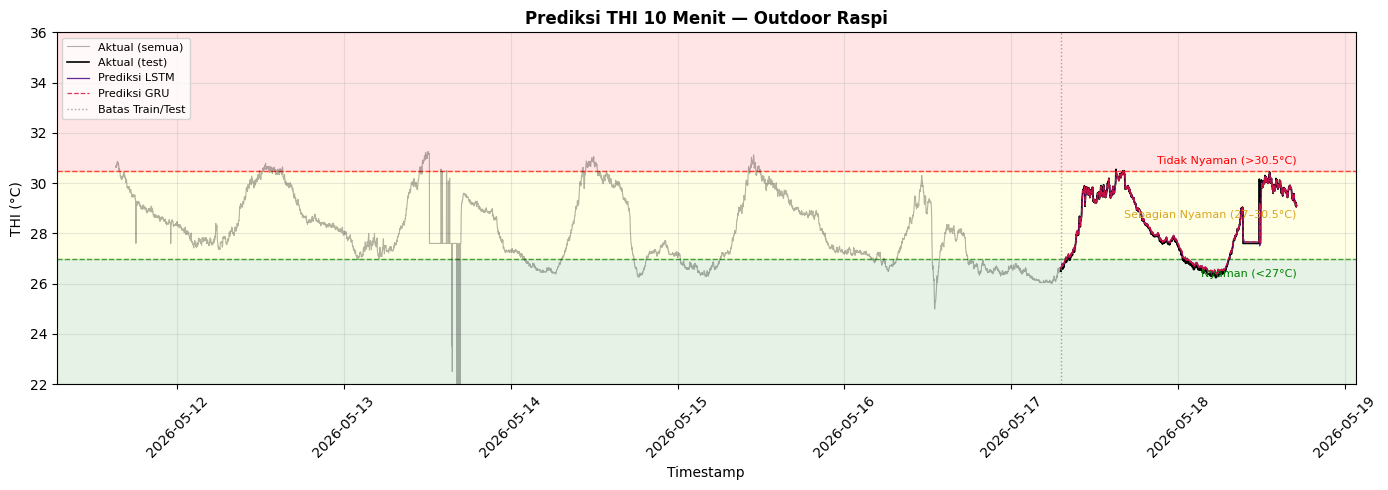

✅ Outdoor Raspi — 10 menit tersimpan!


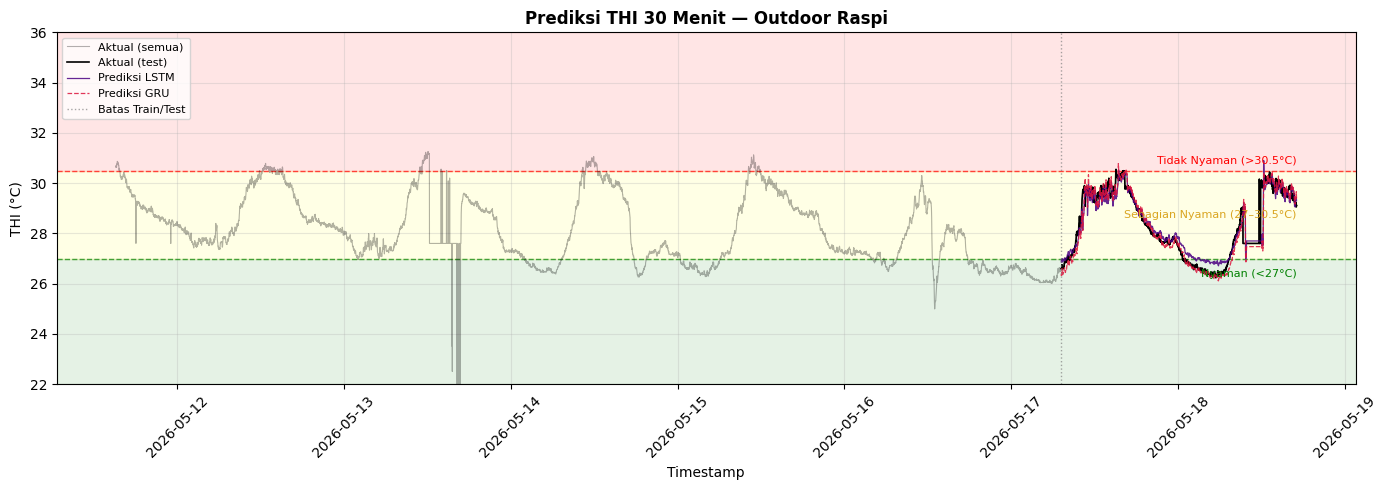

✅ Outdoor Raspi — 30 menit tersimpan!


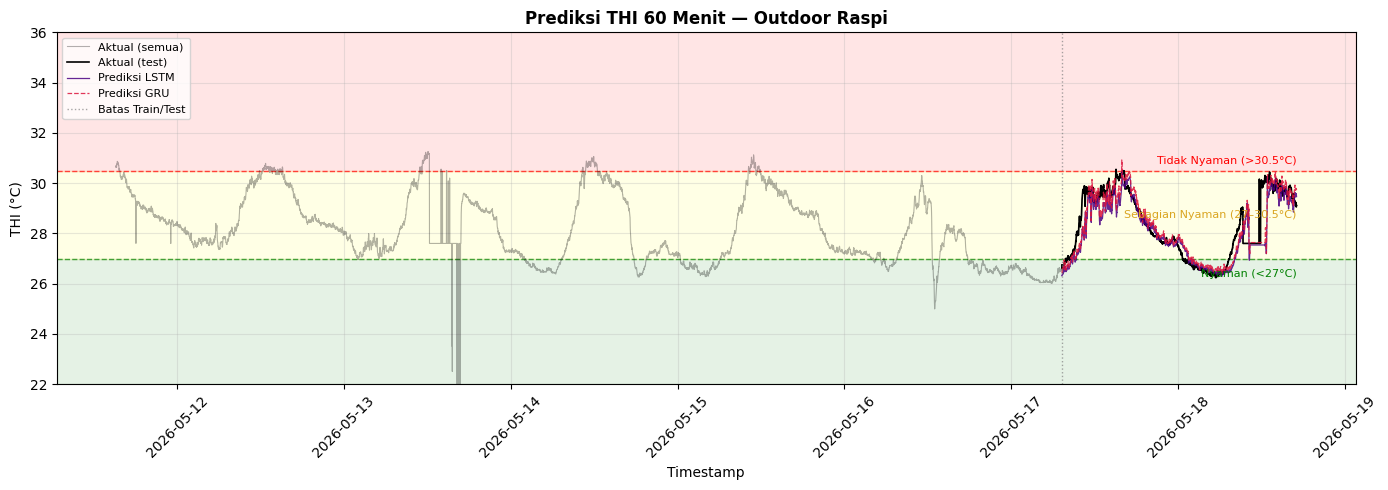

✅ Outdoor Raspi — 60 menit tersimpan!


In [23]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import pandas as pd

base = 'D:/SEMESTER 6/magang things/DATA/'

THI_NYAMAN   = 27.0
THI_SEBAGIAN = 30.5

sensor_config = {
    'Indoor ESP'   : 'inesp',
    'Indoor Raspi' : 'inpi3',
    'Outdoor ESP'  : 'outesp',
    'Outdoor Raspi': 'outpi3',
}
horizons = [10, 30, 60]

for sensor, folder in sensor_config.items():
    for h in horizons:
        # Baca file
        df_lstm = pd.read_excel(f'{base}{folder}/LSTM/LSTM_THI_{h}.xlsx')
        df_gru  = pd.read_excel(f'{base}{folder}/GRU/GRU_THI_{h}.xlsx')

        # Bersihkan kolom
        df_lstm.columns = df_lstm.columns.str.strip()
        df_gru.columns  = df_gru.columns.str.strip()

        # Data test (ada prediksi)
        waktu_test = pd.to_datetime(df_lstm['Waktu'])
        aktual_test = df_lstm['Aktual']
        pred_lstm   = df_lstm['Prediksi LSTM']
        pred_gru    = df_gru['Prediksi GRU']

        # Data aktual full (baca dari QC file)
        df_qc = pd.read_excel(f'{base}{folder}/QC_{folder}.xlsx')
        df_qc.columns = df_qc.columns.str.strip()
        waktu_full  = pd.to_datetime(df_qc['Waktu'])
        ta_full     = df_qc['TA'].values
        rh_full     = df_qc['RH'].values
        aktual_full = 0.8 * ta_full + (ta_full * rh_full) / 500

        # ── Plot ──────────────────────────────────────────────────────
        fig, ax = plt.subplots(figsize=(14, 5))
        fig.patch.set_color('white')

        ymin, ymax = 22, 36

        # Background kategori
        ax.axhspan(ymin,         THI_NYAMAN,   alpha=0.1, color='green')
        ax.axhspan(THI_NYAMAN,   THI_SEBAGIAN, alpha=0.1, color='yellow')
        ax.axhspan(THI_SEBAGIAN, ymax,         alpha=0.1, color='red')

        # Garis kategori
        ax.axhline(THI_NYAMAN,   color='green', lw=1, ls='--', alpha=0.7)
        ax.axhline(THI_SEBAGIAN, color='red',   lw=1, ls='--', alpha=0.7)

        # Label kategori di kanan
        ax.text(waktu_full.iloc[-1], THI_NYAMAN - 0.4,
                'Nyaman (<27°C)', color='green',
                fontsize=8, ha='right', va='top')
        ax.text(waktu_full.iloc[-1], THI_SEBAGIAN + 0.2,
                'Tidak Nyaman (>30.5°C)', color='red',
                fontsize=8, ha='right', va='bottom')
        ax.text(waktu_full.iloc[-1], (THI_NYAMAN + THI_SEBAGIAN)/2,
                'Sebagian Nyaman (27–30.5°C)', color='goldenrod',
                fontsize=8, ha='right', va='center')

        # Plot aktual full (training + test) — transparan
        ax.plot(waktu_full, aktual_full, color='black', lw=0.8,
                alpha=0.3, label='Aktual (semua)')

        # Plot aktual test — tebal
        ax.plot(waktu_test, aktual_test, color='black', lw=1.2,
                alpha=1.0, label='Aktual (test)')

        # Plot prediksi
        ax.plot(waktu_test, pred_lstm, color='indigo',  lw=0.9,
                label='Prediksi LSTM', alpha=0.85)
        ax.plot(waktu_test, pred_gru,  color='crimson', lw=0.9,
                label='Prediksi GRU', alpha=0.85, ls='--')

        # Garis pemisah train/test
        ax.axvline(waktu_test.iloc[0], color='gray', lw=1,
                   ls=':', alpha=0.7, label='Batas Train/Test')

        ax.set_ylim(ymin, ymax)
        ax.set_title(f'Prediksi THI {h} Menit — {sensor}',
                     fontsize=12, fontweight='bold')
        ax.set_xlabel('Timestamp')
        ax.set_ylabel('THI (°C)')
        ax.legend(loc='upper left', fontsize=8)
        ax.grid(True, alpha=0.3)
        plt.xticks(rotation=45)
        plt.tight_layout()

        # Simpan
        fname = f'{base}Plot_THI_{sensor.replace(" ", "_")}_{h}mnt.pdf'
        plt.savefig(fname, bbox_inches='tight')
        plt.show()
        print(f'✅ {sensor} — {h} menit tersimpan!')

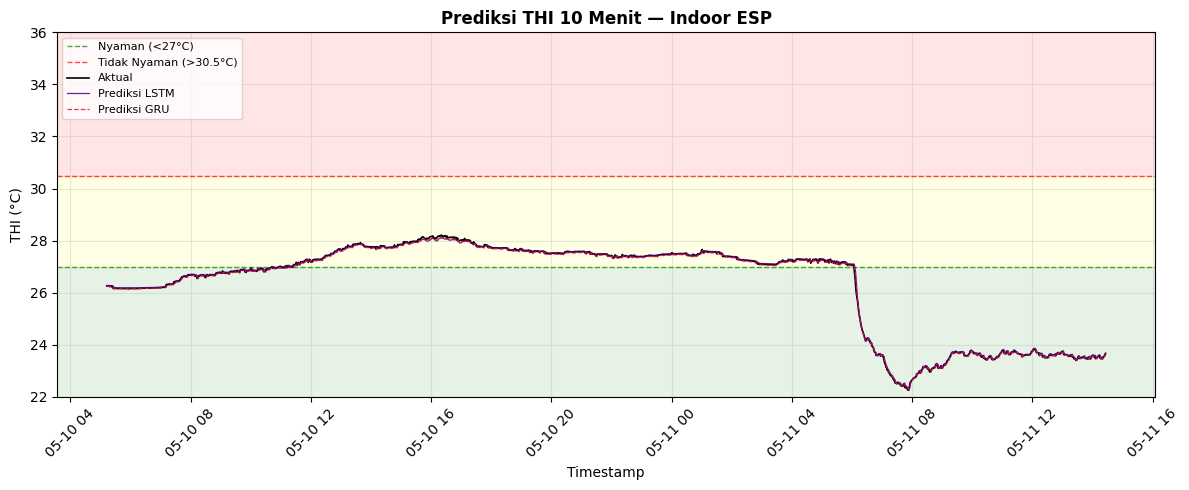

✅ Indoor ESP — 10 menit tersimpan!


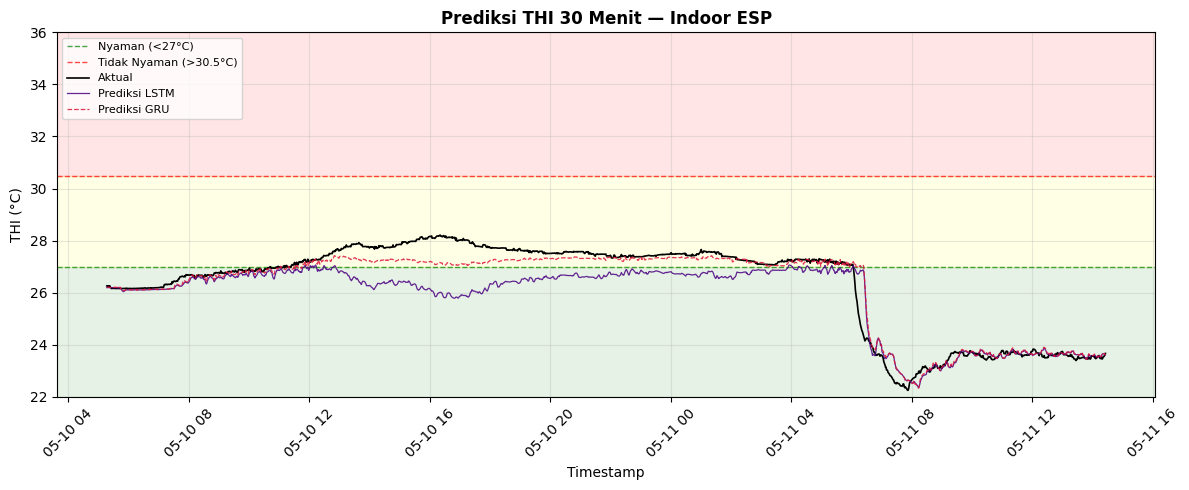

✅ Indoor ESP — 30 menit tersimpan!


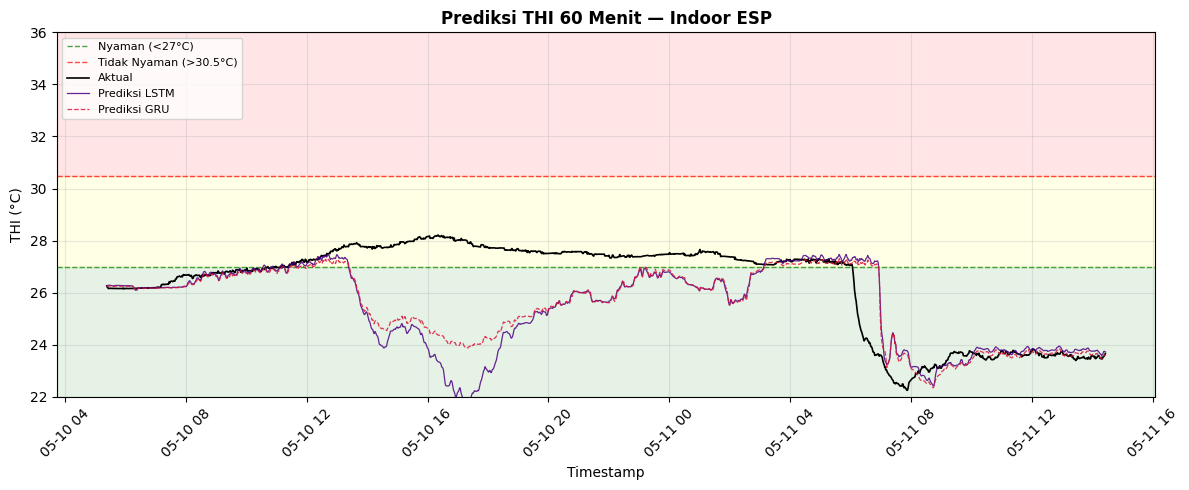

✅ Indoor ESP — 60 menit tersimpan!


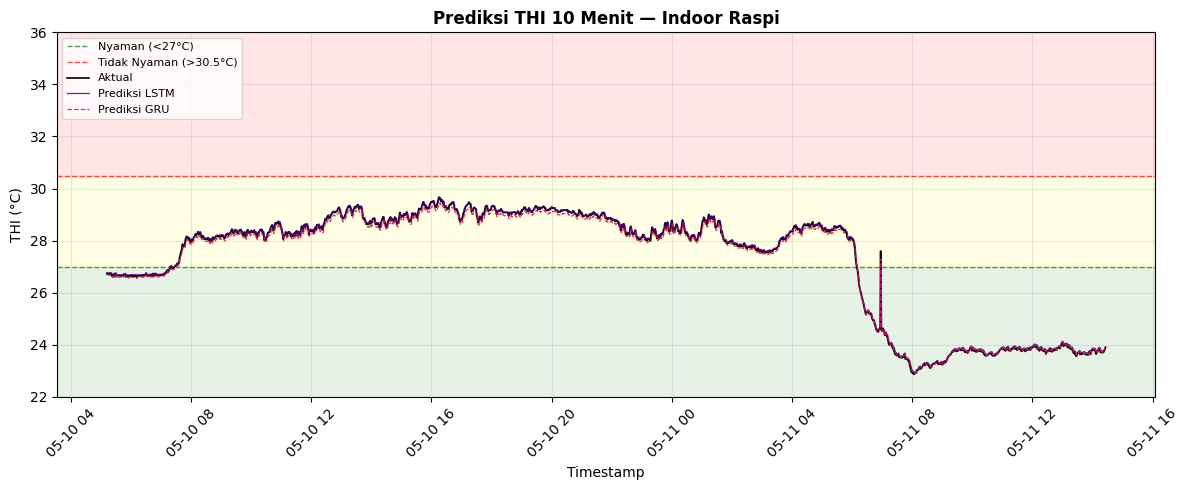

✅ Indoor Raspi — 10 menit tersimpan!


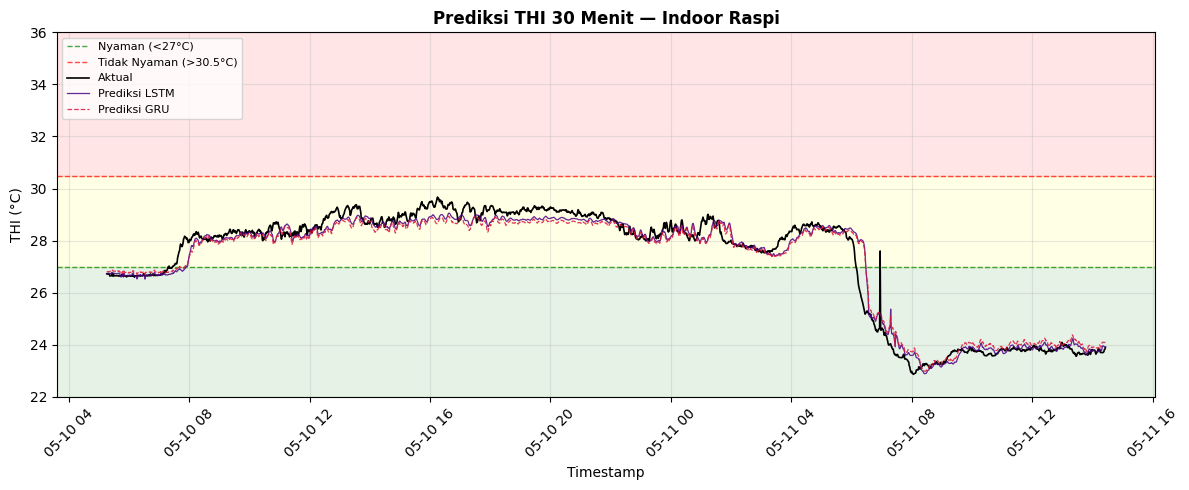

✅ Indoor Raspi — 30 menit tersimpan!


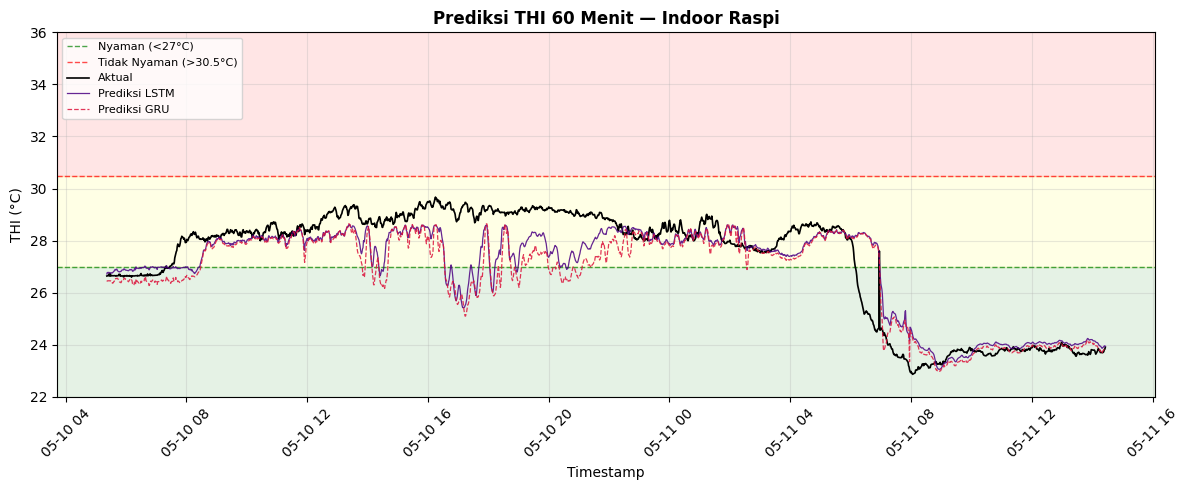

✅ Indoor Raspi — 60 menit tersimpan!


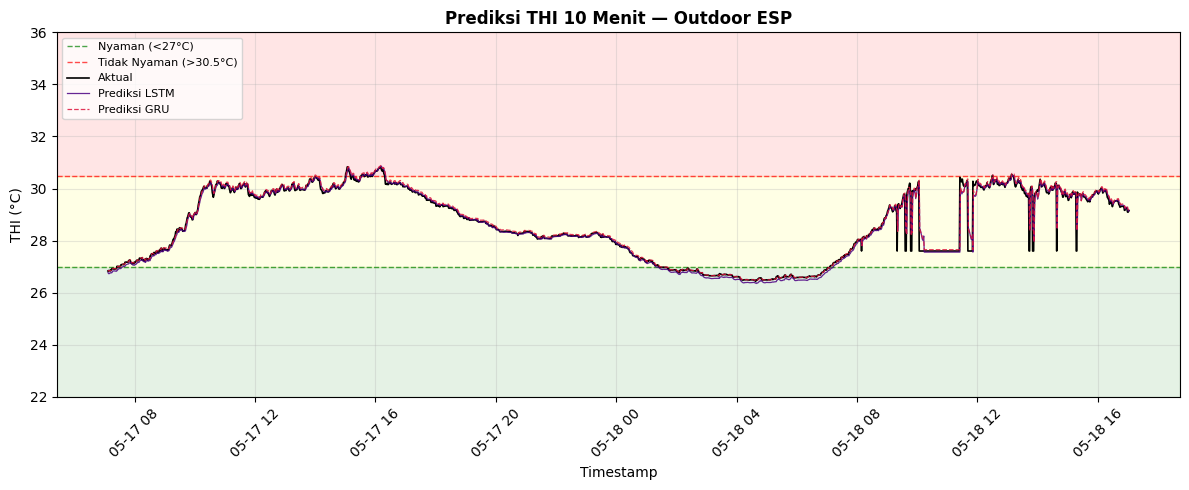

✅ Outdoor ESP — 10 menit tersimpan!


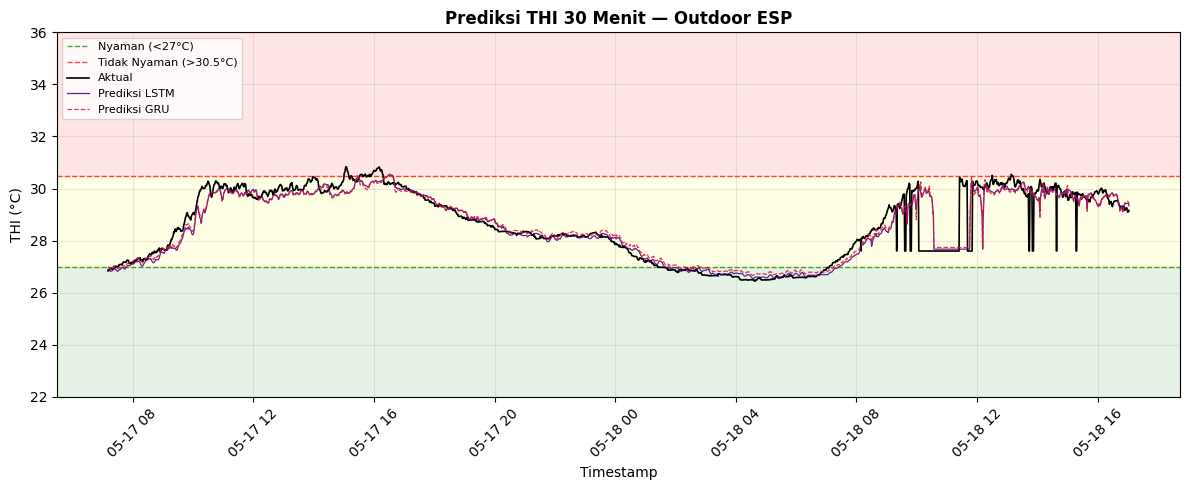

✅ Outdoor ESP — 30 menit tersimpan!


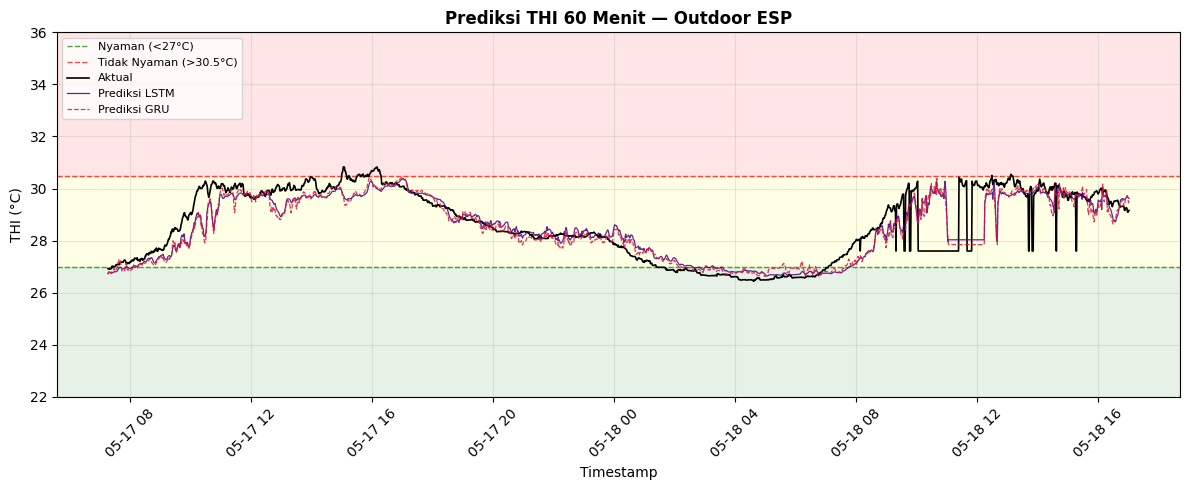

✅ Outdoor ESP — 60 menit tersimpan!


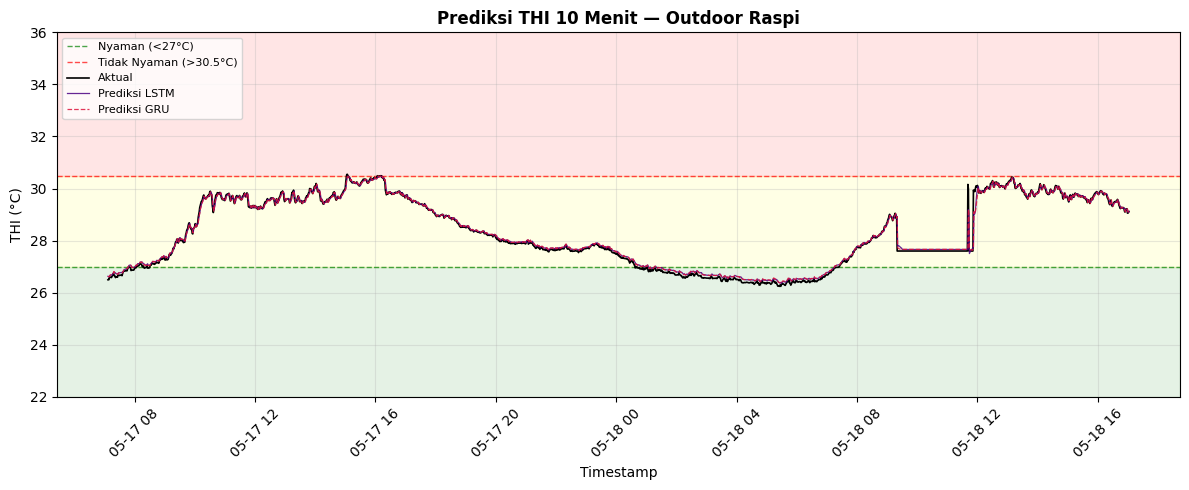

✅ Outdoor Raspi — 10 menit tersimpan!


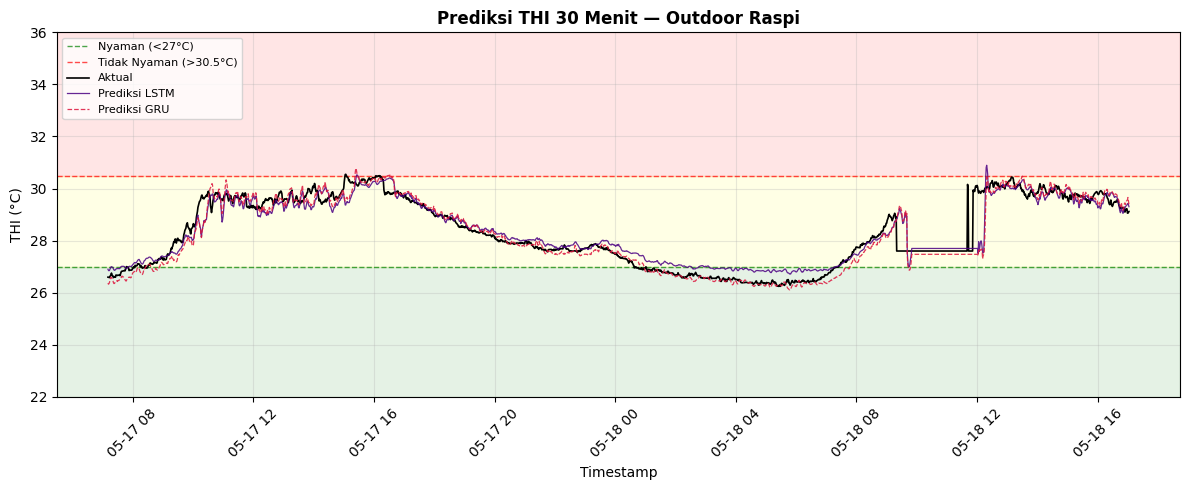

✅ Outdoor Raspi — 30 menit tersimpan!


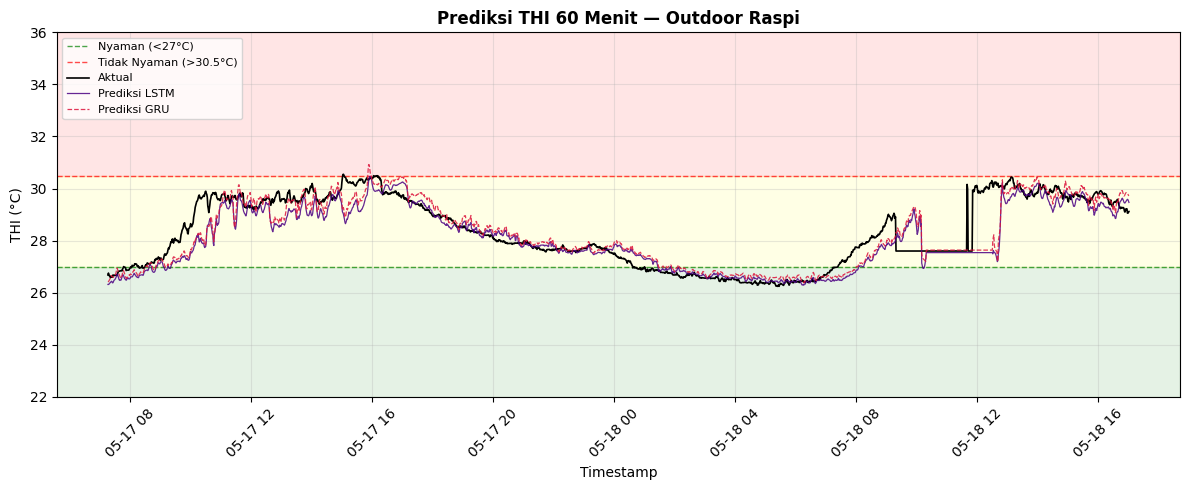

✅ Outdoor Raspi — 60 menit tersimpan!


In [24]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import pandas as pd

base = 'D:/SEMESTER 6/magang things/DATA/'

THI_NYAMAN   = 27.0
THI_SEBAGIAN = 30.5

sensor_config = {
    'Indoor ESP'   : 'inesp',
    'Indoor Raspi' : 'inpi3',
    'Outdoor ESP'  : 'outesp',
    'Outdoor Raspi': 'outpi3',
}
horizons = [10, 30, 60]

for sensor, folder in sensor_config.items():
    for h in horizons:
        # Baca file
        df_lstm = pd.read_excel(f'{base}{folder}/LSTM/LSTM_THI_{h}.xlsx')
        df_gru  = pd.read_excel(f'{base}{folder}/GRU/GRU_THI_{h}.xlsx')

        # Bersihkan kolom
        df_lstm.columns = df_lstm.columns.str.strip()
        df_gru.columns  = df_gru.columns.str.strip()

        # Ambil semua data test
        waktu     = pd.to_datetime(df_lstm['Waktu'])
        aktual    = df_lstm['Aktual']
        pred_lstm = df_lstm['Prediksi LSTM']
        pred_gru  = df_gru['Prediksi GRU']

        # ── Plot ──────────────────────────────────────────────────────
        fig, ax = plt.subplots(figsize=(12, 5))
        fig.patch.set_color('white')

        ymin, ymax = 22, 36

        # Background kategori
        ax.axhspan(ymin,         THI_NYAMAN,   alpha=0.1, color='green')
        ax.axhspan(THI_NYAMAN,   THI_SEBAGIAN, alpha=0.1, color='yellow')
        ax.axhspan(THI_SEBAGIAN, ymax,         alpha=0.1, color='red')

        # Garis kategori
        ax.axhline(THI_NYAMAN,   color='green', lw=1, ls='--', alpha=0.7,
                   label='Nyaman (<27°C)')
        ax.axhline(THI_SEBAGIAN, color='red',   lw=1, ls='--', alpha=0.7,
                   label='Tidak Nyaman (>30.5°C)')

        # Label kategori di kanan
        ax.text(waktu.iloc[-1], THI_NYAMAN - 0.4,
                'Nyaman (<27°C)', color='green',
                fontsize=8, ha='right', va='top')
        ax.text(waktu.iloc[-1], THI_SEBAGIAN + 0.2,
                'Tidak Nyaman (>30.5°C)', color='red',
                fontsize=8, ha='right', va='bottom')
        ax.text(waktu.iloc[-1], (THI_NYAMAN + THI_SEBAGIAN)/2,
                'Sebagian Nyaman (27–30.5°C)', color='goldenrod',
                fontsize=8, ha='right', va='center')

        # Plot data
        ax.plot(waktu, aktual,    color='black', lw=1.2, label='Aktual')
        ax.plot(waktu, pred_lstm, color='indigo',  lw=0.9, label='Prediksi LSTM', alpha=0.85)
        ax.plot(waktu, pred_gru,  color='crimson', lw=0.9, label='Prediksi GRU',
                alpha=0.85, ls='--')

        ax.set_ylim(ymin, ymax)
        ax.set_title(f'Prediksi THI {h} Menit — {sensor}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Timestamp')
        ax.set_ylabel('THI (°C)')
        ax.legend(loc='upper left', fontsize=8)
        ax.grid(True, alpha=0.3)
        plt.xticks(rotation=45)
        plt.tight_layout()

        # Simpan
        fname = f'{base}Plot_THI_{sensor.replace(" ", "_")}_{h}mnt.pdf'
        plt.savefig(fname, bbox_inches='tight')
        plt.show()
        print(f'✅ {sensor} — {h} menit tersimpan!')

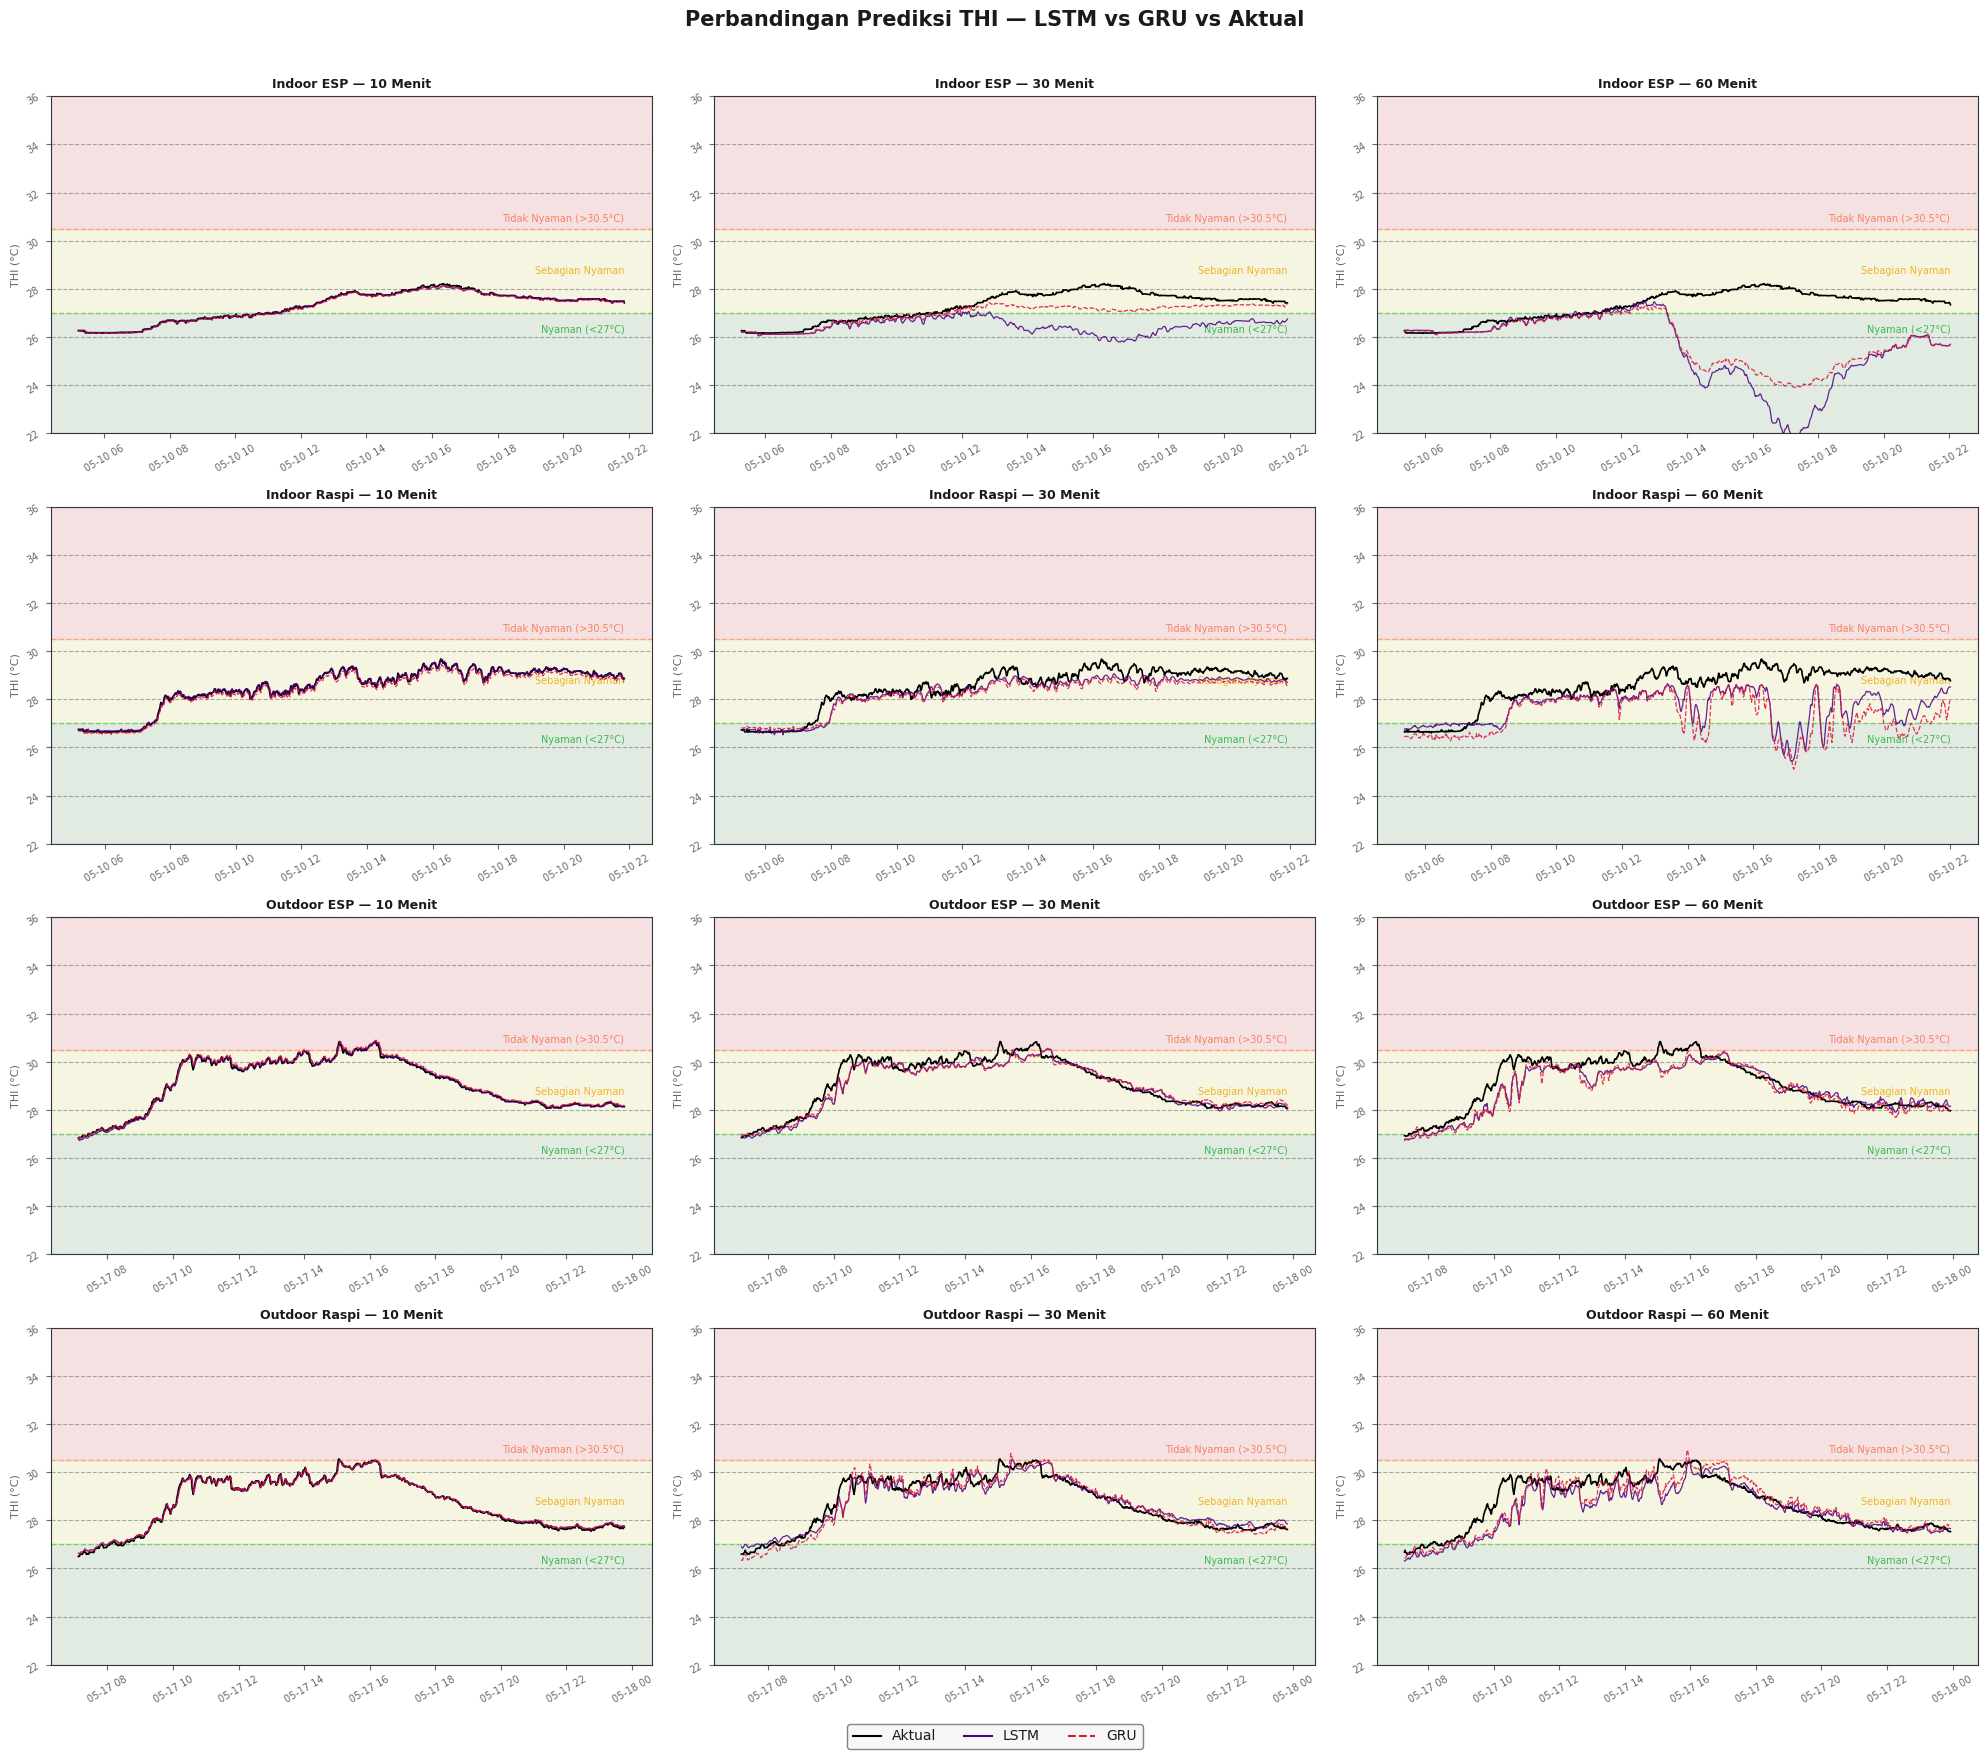

 Visualisasi prediksi tersimpan!


In [29]:
# Garis kategori THI
THI_NYAMAN      = 27.0
THI_SEBAGIAN    = 30.5

def plot_prediksi_sensor(sensor, horizon, ax):
    df_lstm = hasil[sensor][horizon]['lstm']
    df_gru  = hasil[sensor][horizon]['gru']

    # Ambil 1000 data pertama biar tidak terlalu padat
    n = min(1000, len(df_lstm))
    waktu  = df_lstm['Waktu'].iloc[:n]
    aktual = df_lstm['Aktual'].iloc[:n]

    # Ambil nama kolom prediksi
    col_lstm = [c for c in df_lstm.columns if 'Prediksi' in c or 'LSTM' in c.upper()][-1]
    col_gru  = [c for c in df_gru.columns  if 'Prediksi' in c or 'GRU'  in c.upper()][-1]

    pred_lstm = df_lstm[col_lstm].iloc[:n]
    pred_gru  = df_gru[col_gru].iloc[:n]

    # Background kategori
    ymin, ymax = 22, 36
    ax.axhspan(ymin,         THI_NYAMAN,   alpha=0.08, color='green', zorder=0)
    ax.axhspan(THI_NYAMAN,   THI_SEBAGIAN, alpha=0.08, color='yellow', zorder=0)
    ax.axhspan(THI_SEBAGIAN, ymax,         alpha=0.08, color='red', zorder=0)

    # Garis kategori
    ax.axhline(THI_NYAMAN,   color='#3FB950', lw=1, ls='--', alpha=0.6)
    ax.axhline(THI_SEBAGIAN, color='#F78166', lw=1, ls='--', alpha=0.6)

    # Label kategori
    ax.text(waktu.iloc[-1], THI_NYAMAN   - 0.5, 'Nyaman (<27°C)',
            color='#3FB950', fontsize=7, ha='right', va='top')
    ax.text(waktu.iloc[-1], THI_SEBAGIAN + 0.2, 'Tidak Nyaman (>30.5°C)',
            color='#F78166', fontsize=7, ha='right', va='bottom')
    ax.text(waktu.iloc[-1], (THI_NYAMAN + THI_SEBAGIAN)/2, 'Sebagian Nyaman',
            color='#F0B429', fontsize=7, ha='right', va='center')

    # Plot garis
    ax.plot(waktu, aktual,    color='black',  lw=1.2, label='Aktual', zorder=3)
    ax.plot(waktu, pred_lstm, color='indigo',  lw=0.9, label='LSTM',   zorder=3, alpha=0.85)
    ax.plot(waktu, pred_gru,  color='crimson', lw=0.9, label='GRU',    zorder=3, alpha=0.85, ls='--')

    ax.set_ylim(ymin, ymax)
    ax.set_title(f'{sensor} — {horizon} Menit', color=TEXT, fontsize=9, fontweight='bold')
    ax.tick_params(colors=MUTED, labelsize=7, rotation=30)
    ax.set_ylabel('THI (°C)', color=MUTED, fontsize=8)
    ax.set_facecolor(CARD)
    for spine in ax.spines.values():
        spine.set_color('#30363D')
    ax.grid(axis='y', color='#30363D', ls='--', alpha=0.4)

# Plot: 4 sensor × 3 horizon = 12 subplot
fig, axes = plt.subplots(4, 3, figsize=(20, 18), facecolor=BG)
fig.patch.set_facecolor(BG)
fig.suptitle('Perbandingan Prediksi THI — LSTM vs GRU vs Aktual',
             color=TEXT, fontsize=15, fontweight='bold', y=0.98)

for row, sensor in enumerate(sensors):
    for col, h in enumerate(horizons):
        plot_prediksi_sensor(sensor, h, axes[row][col])

# Legend global
legend_elements = [
    Line2D([0], [0], color='black',   lw=1.5, label='Aktual'),
    Line2D([0], [0], color='indigo',  lw=1.5, label='LSTM'),
    Line2D([0], [0], color='crimson', lw=1.5, ls='--', label='GRU'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3,
           facecolor=CARD, edgecolor=MUTED, labelcolor=TEXT,
           fontsize=10, bbox_to_anchor=(0.5, 0.01))

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.savefig('D:/SEMESTER 6/magang things/DATA/Prediksi_LSTM_GRU_Aktual.png',
            dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print(' Visualisasi prediksi tersimpan!')

### **perbandingan loss**

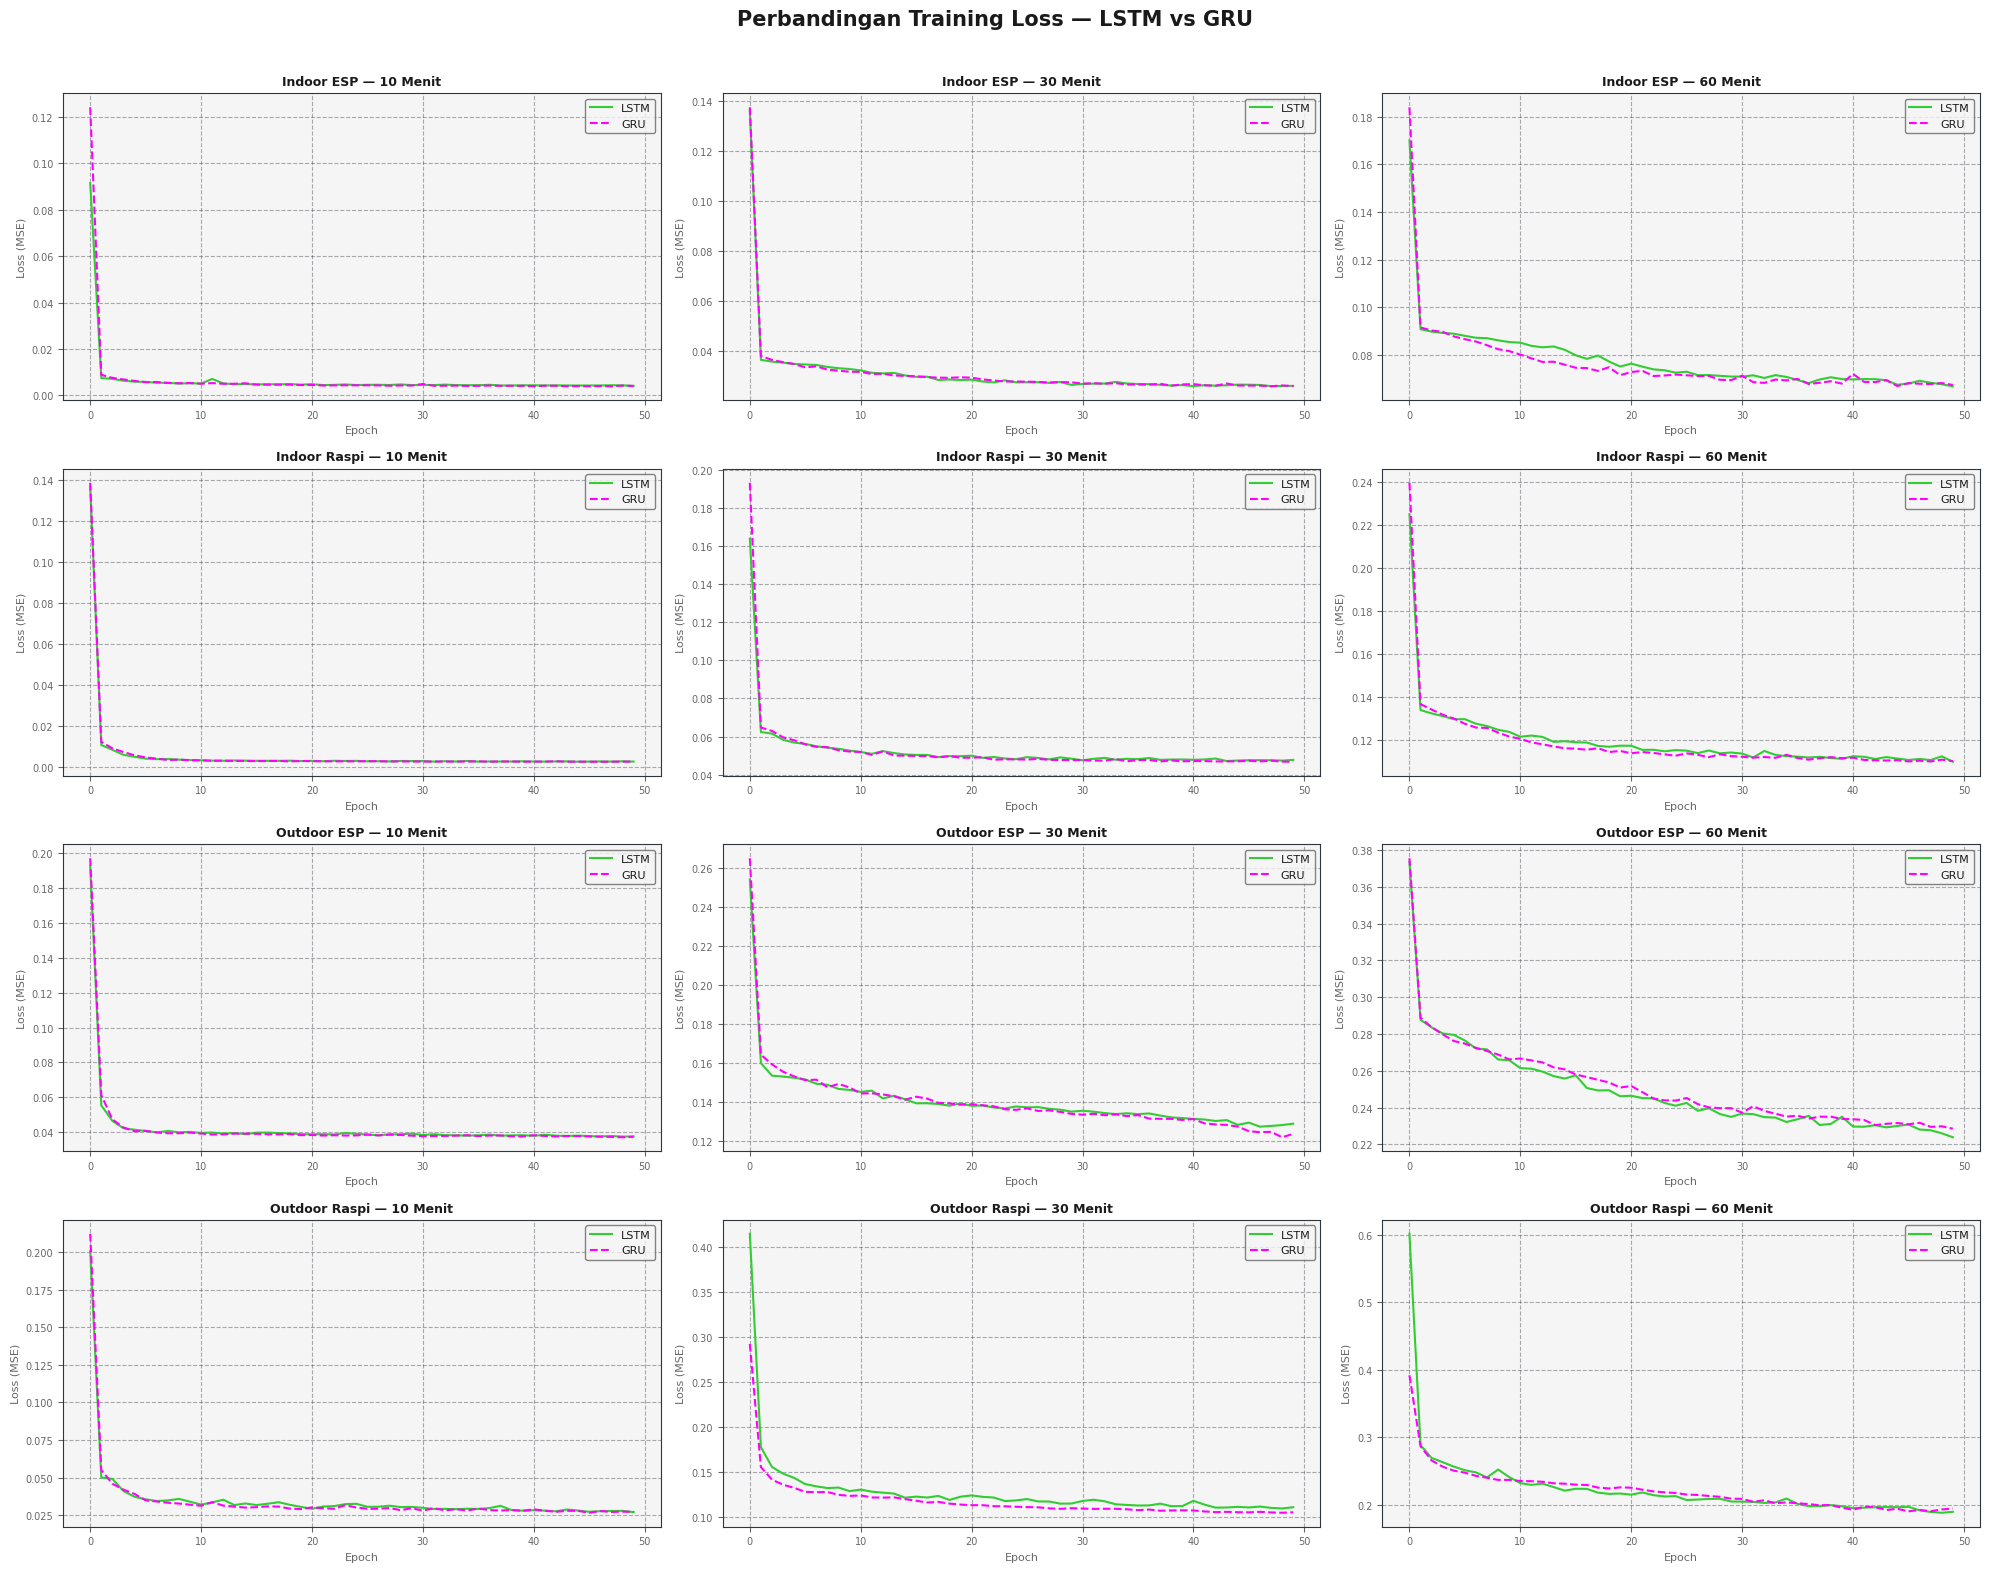

 Visualisasi loss tersimpan!


In [35]:
fig, axes = plt.subplots(4, 3, figsize=(20, 16), facecolor=BG)
fig.patch.set_facecolor(BG)
fig.suptitle('Perbandingan Training Loss — LSTM vs GRU',
             color=TEXT, fontsize=15, fontweight='bold', y=0.98)

for row, sensor in enumerate(sensors):
    for col, h in enumerate(horizons):
        ax = axes[row][col]
        ax.set_facecolor(CARD)
        for spine in ax.spines.values():
            spine.set_color('#30363D')

        df_lstm_loss = loss[sensor][h]['lstm']
        df_gru_loss  = loss[sensor][h]['gru']

        ax.plot(df_lstm_loss['Epochs'], df_lstm_loss['Loss'],
                color='limegreen', lw=1.5, label='LSTM')
        ax.plot(df_gru_loss['Epochs'],  df_gru_loss['Loss'],
                color='fuchsia',  lw=1.5, label='GRU', ls='--')

        ax.set_title(f'{sensor} — {h} Menit', color=TEXT, fontsize=9, fontweight='bold')
        ax.set_xlabel('Epoch', color=MUTED, fontsize=8)
        ax.set_ylabel('Loss (MSE)', color=MUTED, fontsize=8)
        ax.tick_params(colors=MUTED, labelsize=7)
        ax.grid(color='#30363D', ls='--', alpha=0.4)
        ax.legend(facecolor=CARD, edgecolor=MUTED, labelcolor=TEXT, fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('D:/SEMESTER 6/magang things/DATA/Loss_LSTM_GRU.png',
            dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print(' Visualisasi loss tersimpan!')

### **analisis**

Analisis bagaimana hasil prediksi indoor terhadap outdoor

- Sensor indoor unggul di horizon pendek — Indoor ESP horizon 10 menit mencatat R tertinggi (0.9997–0.9998) dan RMSE terendah (0.046–0.047) dari semua sensor<br><br>
- Sensor indoor mengalami degradasi lebih tajam di horizon panjang — Indoor ESP horizon 60 menit R anjlok ke 0.44–0.62, RMSE melonjak ke 1.62–1.97, dan MAPE ke 3.96–4.51%<br><br>
- Sensor outdoor lebih stabil di horizon panjang — R masih 0.87–0.89, RMSE di kisaran 0.62–0.66, MAPE 1.38–1.55% pada horizon 60 menit<br><br>
- Data outdoor yang lebih variatif justru membantu model mempertahankan akurasi di horizon panjang — pola perubahan yang lebih beragam memberikan sinyal lebih kaya<br><br>
- Indoor Raspi lebih stabil dari Indoor ESP meski satu lokasi — pada horizon 60 menit RMSE Indoor Raspi (1.04–1.24) masih lebih baik dari Indoor ESP (1.62–1.97), kemungkinan karena perbedaan karakteristik hardware atau penempatan sensor 

Analisis mengapa GRU lebih akurat disbanding LSTM

- GRU tidak selalu lebih akurat — secara keseluruhan LSTM lebih sering unggul di semua metrik (R: 7/12, RMSE: 7/12, MAPE: 8/12)<br><br>
- Keunggulan GRU hanya konsisten di Indoor ESP (8/9) — di sana selisihnya signifikan, RMSE GRU 0.406 vs LSTM 0.859 pada horizon 30 menit, MAPE GRU 0.97% vs LSTM 2.27%<br><br>
- Di Indoor ESP, LSTM overfitting — training loss LSTM lebih rendah (0.026 vs 0.047 di horizon 30 menit) tapi performa ujinya jauh lebih buruk, menunjukkan model gagal generalisasi<br><br>
- GRU lebih tahan overfitting di data homogen — struktur 2 gate yang lebih sederhana membuat generalisasi lebih baik pada data indoor yang flat dan minim variasi<br><br>
- Di sensor lain, justru GRU overfitting — training loss GRU lebih rendah dari LSTM tapi kalah di semua metrik uji, terutama Indoor Raspi dan Outdoor Raspi<br><br>
- LSTM lebih cocok untuk data variatif — cell state-nya lebih mampu menangkap dependensi temporal kompleks, konsisten dengan keunggulan RMSE dan MAPE di sensor outdoor dan Indoor Raspi<br><br>
